# Bài tập về nhà Decision Tree, Random Forest


- Thực hiện các yêu cầu dưới đây với tập dữ liệu Australian credit
- Down dữ liệu tại đường link dưới đây và đặt vào folder  *'/data'*

  https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)
    

# Các bước làm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

random_state = 0


## Tìm hiểu dữ liệu

In [2]:
data_path = '../data/australian.dat'
credit = np.genfromtxt(data_path)
X, y = credit[:, :-1], credit[:, -1]

print("Dữ liệu Australian Credit")
print("Shape:", X.shape, y.shape)
print("Các giá trị nhãn:", np.unique(y))
print("Phân phối nhãn:", {int(label): int(np.sum(y == label)) for label in np.unique(y)})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Dữ liệu Australian Credit
Shape: (690, 14) (690,)
Các giá trị nhãn: [0. 1.]
Phân phối nhãn: {0: 383, 1: 307}
Train shape: (552, 14) | Test shape: (138, 14)


##  Decision Tree

###  Khảo sát với các giá trị khác nhau của max_depth

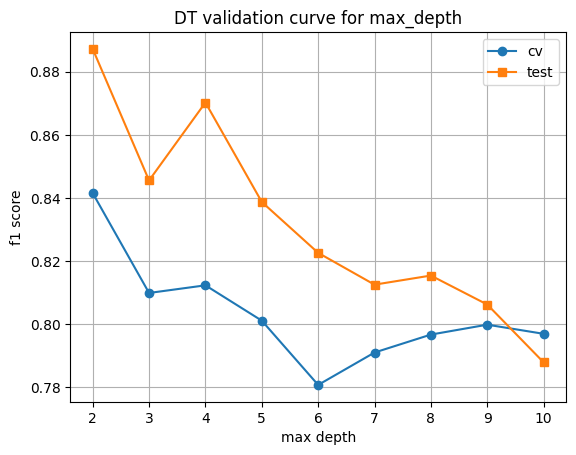

In [3]:
cv_scores_by_depth, test_scores_by_depth = [], []
max_depth_values = np.arange(2, 11)

for curr_max_depth in max_depth_values:
    tree = DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)

    # cross-validation
    val_scores = cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
    cv_scores_by_depth.append(val_scores.mean())

    # test
    tree.fit(X_train, y_train)
    curr_pred = tree.predict(X_test)
    test_scores_by_depth.append(f1_score(y_test, curr_pred))

plt.figure()
plt.plot(max_depth_values, cv_scores_by_depth, label='cv', marker='o')
plt.plot(max_depth_values, test_scores_by_depth, label='test', marker='s')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('f1 score')
plt.title('DT validation curve for max_depth')
plt.grid(True)
plt.show()


###  Parameter tuning    

In [4]:
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier(random_state=random_state)
    if algorithm == 'random-forest':
        model = RandomForestClassifier(random_state=random_state)
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                              n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end=': ')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model):
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))
    print("-" * 50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)
evaluate(best_tree)


Best model: DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=50,
                       random_state=0)
Train Accuracy : 0.8641304347826086
Train f1 score : 0.8440748440748441
--------------------------------------------------
Test Accuracy : 0.855072463768116
Test f1 score : 0.8360655737704918
Test Confusion Matrix:
[[67  6]
 [14 51]]


###  Feature importance & Learning curve (Decision Tree)


Feature importances (Decision Tree):
  Feature  7 - 0.7715
  Feature  8 - 0.1262
  Feature 13 - 0.0492
  Feature  2 - 0.0265
  Feature 12 - 0.0186
  Feature  1 - 0.0080
  Feature  9 - 0.0000
  Feature 10 - 0.0000
  Feature 11 - 0.0000
  Feature  6 - 0.0000
  Feature  4 - 0.0000
  Feature  5 - 0.0000
  Feature  3 - 0.0000
  Feature  0 - 0.0000


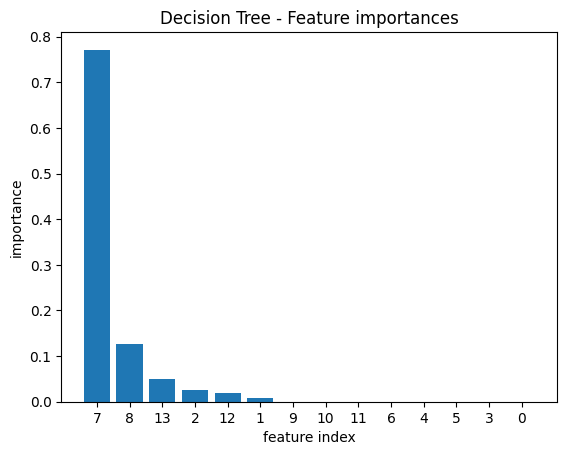

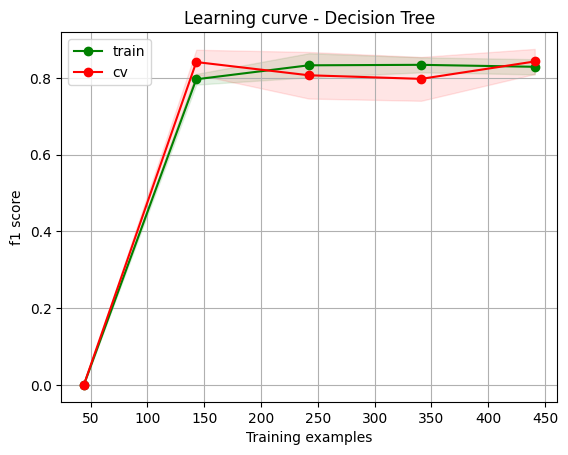

In [5]:
# ===== Decision Tree: Feature importance & Learning curve =====

# Helper: vẽ learning curve (train vs cv) theo f1
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5))
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    plt.figure()
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='g')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='r')
    plt.plot(train_sizes, train_mean, 'o-', color='g', label='train')
    plt.plot(train_sizes, val_mean, 'o-', color='r', label='cv')
    plt.title(title)
    plt.xlabel('Training examples')
    plt.ylabel('f1 score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Feature importance của best_tree (mức giảm Gini mỗi đặc trưng mang lại)
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Feature importances (Decision Tree):')
for i in indices:
    print(f'  Feature {i:2d} - {importances[i]:.4f}')

plt.figure()
plt.title('Decision Tree - Feature importances')
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), indices)
plt.xlabel('feature index')
plt.ylabel('importance')
plt.show()

# Learning curve của best_tree
plot_learning_curve(best_tree, 'Learning curve - Decision Tree', X_train, y_train, cv=5)



## Random Forest

### Khảo sát với các giá trị khác nhau của num_trees

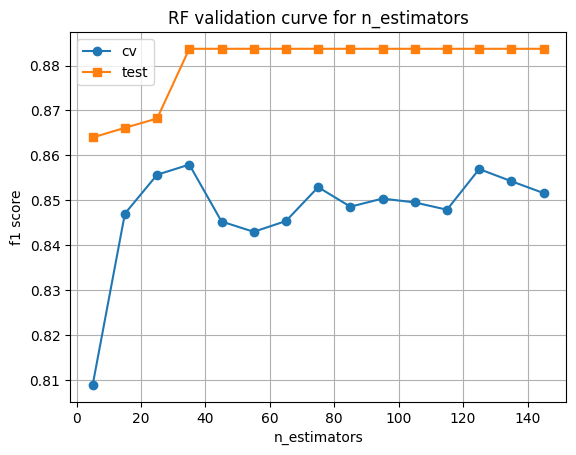

In [6]:
cv_scores_by_trees, test_scores_by_trees = [], []
num_trees = np.arange(5, 151, 10)

for ntrees in num_trees:
    rf = RandomForestClassifier(n_estimators=ntrees, random_state=random_state, n_jobs=-1)
    val_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')
    cv_scores_by_trees.append(val_scores.mean())
    rf.fit(X_train, y_train)
    curr_pred = rf.predict(X_test)
    test_scores_by_trees.append(f1_score(y_test, curr_pred))

plt.figure()
plt.plot(num_trees, cv_scores_by_trees, label='cv', marker='o')
plt.plot(num_trees, test_scores_by_trees, label='test', marker='s')
plt.legend()
plt.xlabel('n_estimators')
plt.ylabel('f1 score')
plt.title('RF validation curve for n_estimators')
plt.grid(True)
plt.show()


### Parameter tuning

In [7]:
dict_param_rf = {
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ["gini", "entropy"],
    'n_estimators': [50, 100, 150]
}
best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param_rf)
evaluate(best_forest)


Best model: RandomForestClassifier(max_depth=15, n_estimators=150, random_state=0)
Train Accuracy : 1.0
Train f1 score : 1.0
--------------------------------------------------
Test Accuracy : 0.8913043478260869
Test f1 score : 0.883720930232558
Test Confusion Matrix:
[[66  7]
 [ 8 57]]


### Feature importance & Learning curve (Random Forest)


Feature importances (Random Forest):
  Feature  7 - 0.2658
  Feature  6 - 0.1063
  Feature  9 - 0.0939
  Feature  2 - 0.0884
  Feature 13 - 0.0846
  Feature  4 - 0.0818
  Feature  1 - 0.0696
  Feature 12 - 0.0642
  Feature  8 - 0.0621
  Feature  5 - 0.0294
  Feature  3 - 0.0179
  Feature 11 - 0.0130
  Feature 10 - 0.0117
  Feature  0 - 0.0112


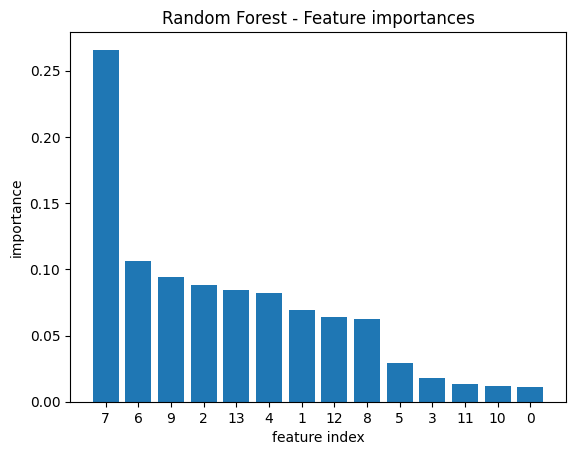

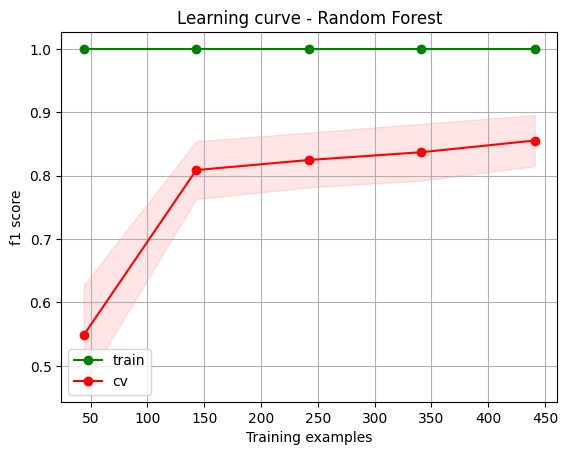

In [8]:
# ===== Random Forest: Feature importance & Learning curve =====

# Feature importance của best_forest (trung bình mức giảm Gini trên toàn rừng)
importances = best_forest.feature_importances_
indices = np.argsort(importances)[::-1]
print('Feature importances (Random Forest):')
for i in indices:
    print(f'  Feature {i:2d} - {importances[i]:.4f}')

plt.figure()
plt.title('Random Forest - Feature importances')
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), indices)
plt.xlabel('feature index')
plt.ylabel('importance')
plt.show()

# Learning curve của best_forest
plot_learning_curve(best_forest, 'Learning curve - Random Forest', X_train, y_train, cv=5)



## Nhận xét & So sánh

- **Validation curve:** đường f1 theo `max_depth` (DT) cho thấy mô hình quá khớp khi cây quá sâu (f1 cv giảm dù f1 train tăng); đường f1 theo `n_estimators` (RF) tăng rồi **bão hoà** — thêm cây gần như không cải thiện, chỉ tốn thời gian.
- **best_tree vs best_forest:** so sánh accuracy / f1 trên tập test (in ra từ `evaluate`). Random Forest thường cho f1 cao hơn và **phương sai thấp hơn** một cây đơn lẻ nhờ bagging + trung bình hoá nhiều cây.
- **Learning curve:** khoảng cách giữa đường *train* (xanh) và *cv* (đỏ) phản ánh mức quá khớp. Khoảng cách rộng và chưa thu hẹp khi thêm dữ liệu ⇒ variance còn cao (hay gặp ở DT sâu); RF thường có khoảng cách hẹp hơn.
- **Feature importance:** các đặc trưng có độ giảm Gini lớn nhất là nhóm đóng góp chính cho quyết định cấp tín dụng — có thể dùng `SelectFromModel` để rút gọn đặc trưng và kiểm tra mô hình có giữ được hiệu năng không.

